In [19]:
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sensor import get_sensor_tuple_data

In [2]:
mpl.rcParams["axes.titlesize"] = 12
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["legend.title_fontsize"] = 9

In [3]:
with open("raw_sensor_data_plain.pkl", "rb") as f:
    sensor_data_raw = pickle.load(f)

with open("lpf_sensor_data_plain.pkl", "rb") as f:
    sensor_data_lpf = pickle.load(f)

with open("interpolation_functions_plain.pkl", "rb") as f:
    interp_funcs = pickle.load(f)

with open("sensor_labels_plain.pkl", "rb") as f:
    labels = pickle.load(f)

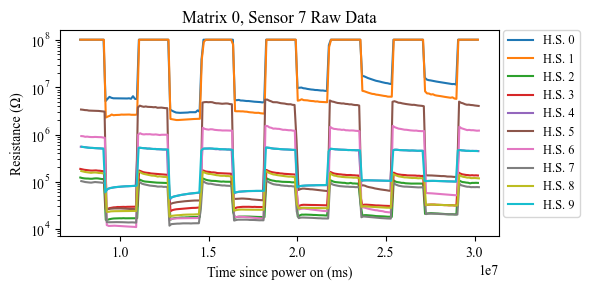

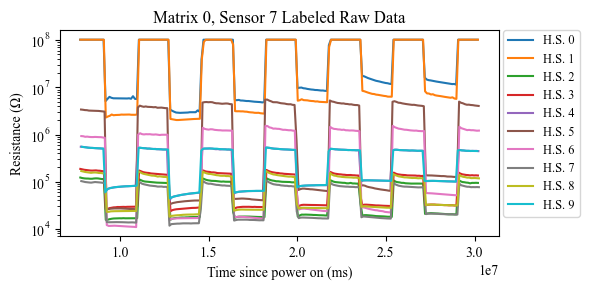

In [22]:
def plot_sensor(matrix, sensor_idx, sensor_data, skip=(1, 1), title=""):
    plt.figure(figsize=(6, 3))
    plt.title(title)
    plt.yscale("log")
    for hp_idx, val in sensor_data[f"mat_{matrix}"][sensor_idx].items():
        resistance = val["Resistance Gassensor"].values
        time_ms = val["Time Since PowerOn"].values
        plt.plot(
            time_ms[skip[0]: -skip[1]],
            resistance[skip[0]: -skip[1]],
            label=f"H.S. {hp_idx}"
        )
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
    plt.xlabel("Time since power on (ms)")
    plt.ylabel("Resistance (Ω)")
    plt.tight_layout()
    plt.savefig(f"figures/{title.replace(",", "")}.pdf", format="pdf", bbox_inches="tight")
    plt.show()


matrix, sensor = 0, 7
title = f"Matrix {matrix}, Sensor {sensor} Raw Data"
plot_sensor(matrix, sensor, sensor_data_raw, skip=(70, 5), title=title)

title = f"Matrix {matrix}, Sensor {sensor} Labeled Raw Data"
plot_sensor(matrix, sensor, sensor_data_raw, skip=(70, 5), title=title)

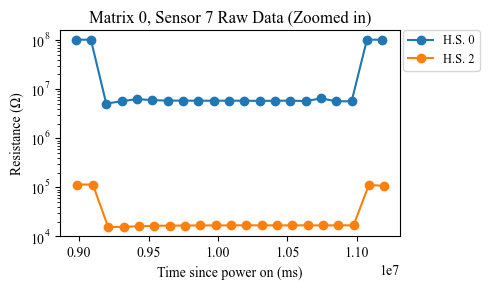

In [23]:
def plot_sensor_zoomed(matrix, sensor_idx, sensor_data, skip_to=(1, 1), title="", hps=[0, 1]):
    plt.figure(figsize=(5, 3))
    plt.title(title)
    plt.yscale("log")
    for hp_idx, val in sensor_data[f"mat_{matrix}"][sensor_idx].items():
        if hp_idx not in hps:
            continue
        resistance = val["Resistance Gassensor"].values
        time_ms = val["Time Since PowerOn"].values
        plt.plot(
            time_ms[skip_to[0]: skip_to[0] + skip_to[1]],
            resistance[skip_to[0]: skip_to[0] + skip_to[1]],
            label=f"H.S. {hp_idx}",
            marker="o",
            linestyle="-"
        )
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
    plt.xlabel("Time since power on (ms)")
    plt.ylabel("Resistance (Ω)")
    plt.tight_layout()
    plt.savefig(
        f"figures/{title.replace(",", "").replace("(", "").replace(")", "")}.pdf",
        format="pdf",
        bbox_inches="tight")
    plt.show()


matrix, sensor = 0, 7
start, to = 81, 21
hps = [0, 2]
title = f"Matrix {matrix}, Sensor {sensor} Raw Data (Zoomed in)"
plot_sensor_zoomed(matrix, sensor, sensor_data_raw,
                   skip_to=(start, to), title=title, hps=hps)

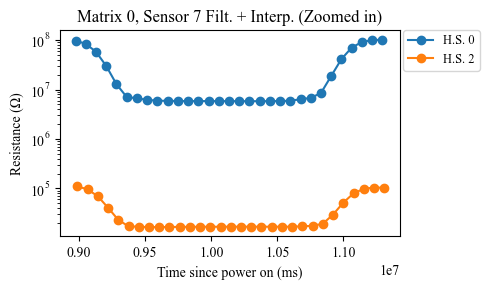

In [24]:
def plot_sensor_zoomed_interploated(matrix, sensor_idx, sensor_data, ips, skip_to=(1, 1), title="", hps=[0, 1]):
    plt.figure(figsize=(5, 3))
    plt.title(title)
    plt.yscale("log")
    for hp_idx, val in sensor_data[f"mat_{matrix}"][sensor_idx].items():
        if hp_idx not in hps:
            continue
        time_ms = val["Time Since PowerOn"].values
        ip = ips[f"mat_{matrix}"][sensor_idx][hp_idx]
        interpolated_time = np.linspace(
            time_ms[skip_to[0]],
            time_ms[skip_to[0] + skip_to[1]],
            int(skip_to[1] * 1.5))
        interpolated_data = ip(interpolated_time)
        plt.plot(
            interpolated_time,
            interpolated_data,
            label=f"H.S. {hp_idx}",
            marker="o",
            linestyle="-"
        )
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
    plt.xlabel("Time since power on (ms)")
    plt.ylabel("Resistance (Ω)")
    plt.tight_layout()
    plt.savefig(
        f"figures/{title.replace(",", "")
                   .replace("(", "")
                   .replace(")", "")
                   .replace("+", "")}.pdf",
        format="pdf",
        bbox_inches="tight")
    plt.show()


title = f"Matrix {matrix}, Sensor {sensor} Filt. + Interp. (Zoomed in)"
plot_sensor_zoomed_interploated(
    matrix, sensor, sensor_data_lpf, interp_funcs, skip_to=(start, to), title=title, hps=hps)

In [25]:
with open(f"sensor_labels_plain.pkl", "rb") as f:
    labels = pickle.load(f)

In [26]:
class Sensor:
    def __init__(self, matrix, sensor_idx, interp_funcs, labels):
        self.interp_funcs = interp_funcs[f"mat_{matrix}"][sensor_idx]
        self.labels = labels[f"mat_{matrix}"]
        self.num_s = 100

    def get_data_for_region(self, region_idx):
        region = self.labels[region_idx]
        Y = []
        t = np.linspace(region["start"], region["end"], self.num_s)
        for hp in range(10):
            y = np.log(self.interp_funcs[hp](t))
            Y.append(y)
        return {
            "y": np.array(Y),  # sensor data
            "label": region["label"],  # clf label
            "reg": region["target"],  # regression target
            "t": t,  # time
        }

    def get_ml_data_for_region(self, region_idx):
        region_data = self.get_data_for_region(region_idx)
        X = region_data["y"]
        y = np.array([region_data["label"]] * self.num_s, dtype=np.int32)
        r = np.array([region_data["reg"]] * self.num_s)
        t = region_data["t"]
        return X.T, y, r, t

    def get_ml_data_list(self):
        X = np.array([[]] * 10)
        y = np.array([], dtype=np.int32)
        r = np.array([])
        t = np.array([])
        for i in range(len(self.labels)):
            region_data = self.get_data_for_region(i)
            X = np.append(X, region_data["y"], axis=1)
            y = np.append(y, np.array([region_data["label"]] * self.num_s))
            r = np.append(r, np.array([region_data["reg"]] * self.num_s))
            t = np.append(t, region_data["t"])
        return X.T, y, r, t  # sensor data, clf label, reg target, time
    
    def get_data_between_times(self, start, end, num_samples):
        Y = []
        t = np.linspace(start, end, num_samples)
        for hp in range(10):
            y = np.log(self.interp_funcs[hp](t))
            Y.append(y)
        
        return np.array(Y), t


def get_sensor_tuple_data(matrix, s_l_idx, s_r_idx, interp_funcs, labels):
    """ 
    Returns: Sensor data, Clf labels, Reg data, Time arr
    """
    s_l = Sensor(matrix, s_l_idx, interp_funcs, labels)
    X_l, y_l, r_l, t_l = s_l.get_ml_data_list()
    s_r = Sensor(matrix, s_r_idx, interp_funcs, labels)
    X_r, y_r, r_r, t_r = s_r.get_ml_data_list()

    if not (y_l == y_r).all():
        raise Exception(f"Classes are not the same!")
    if not (r_l == r_r).all():
        raise Exception(f"Reg targets are not the same!")
    if not (t_l == t_r).all():
        raise Exception(f"Time data are not the same!")

    X_tuple = np.concatenate((X_l, X_r), axis=1)
    return X_tuple, y_l, r_l, t_l  # Sensor data, Clf labels, Reg data, Time arr


def get_sensor_tuple_data_for_region(matrix, s_l_idx, s_r_idx, interp_funcs, labels, region_idx):
    s_l = Sensor(matrix, s_l_idx, interp_funcs, labels)
    X_l, y_l, r_l, t_l = s_l.get_ml_data_for_region(region_idx)
    s_r = Sensor(matrix, s_r_idx, interp_funcs, labels)
    X_r, y_r, r_r, t_r = s_r.get_ml_data_for_region(region_idx)

    if not (y_l == y_r).all():
        raise Exception(f"Classes are not the same!")
    if not (r_l == r_r).all():
        raise Exception(f"Reg targets are not the same!")
    if not (t_l == t_r).all():
        raise Exception(f"Time data are not the same!")

    X_tuple = np.concatenate((X_l, X_r), axis=1)
    return X_tuple, y_l, r_l, t_l  # Sensor data, Clf labels, Reg data, Time arr


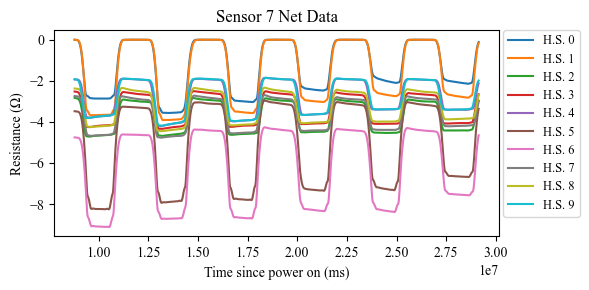

In [33]:
def plot_data_arr(y, t, title, save_as=None):
    plt.figure(figsize=(6, 3))
    plt.title(title)

    for i in range(10):
        plt.plot(
            t,
            y[i],
            label=f"H.S. {i}"
        )

    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
    plt.xlabel("Time since power on (ms)")
    plt.ylabel("Resistance (Ω)")
    plt.tight_layout()
    plt.savefig(
        f"figures/{title.replace(",", "")
                   .replace("(", "")
                   .replace(")", "")
                   .replace("+", "")}.pdf",
        format="pdf",
        bbox_inches="tight")
    plt.show()


s_idx = 7
ns = 1200
s_l = Sensor(0, s_idx, interp_funcs, labels)
y_l, t_l = s_l.get_data_between_times(8792985, 29130008, ns)
s_r = Sensor(1, s_idx, interp_funcs, labels)
y_r, t_r = s_r.get_data_between_times(8809606, 29146898, ns)
plot_data_arr(y_l - y_r, t_l, f"Sensor {s_idx} Net Data", save_as=None)